# Problem 2: Reaction condition optimization
## Q1: Calculating yield based on reaction kinetics

Task 1: Plot the reaction yield vs. reaction time when temperature is 60 °C and catalyst concentration is 3 mM.

Task 2: Plot the reaction yield vs. temperature when reaction time is 40 min and catalyst concentration is 3 mM.

Task 3: Plot the reaction yield vs. catalyst concentration when temperature is 60 °C and reaction time is 40 min.

Evaluating Yield vs Time...
Evaluating Yield vs Temperature...
Evaluating Yield vs Catalyst Concentration...


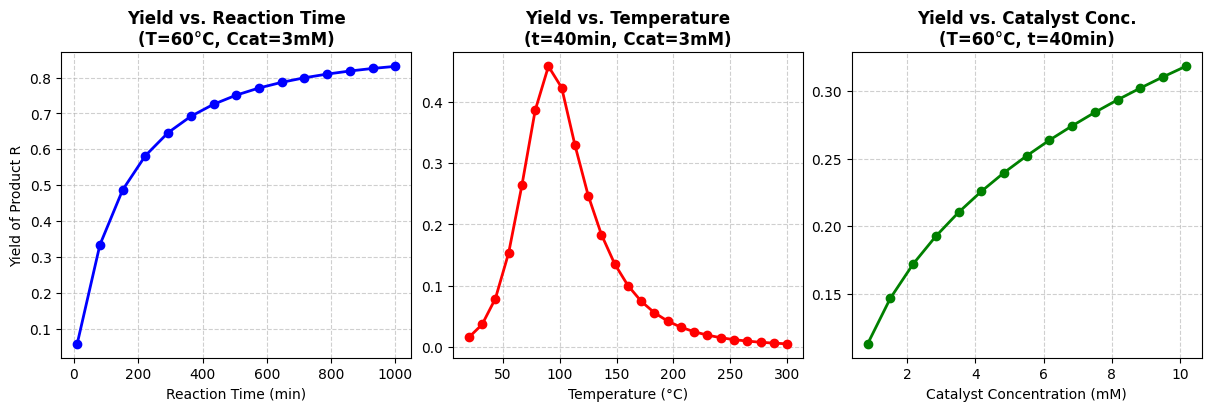

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the kinetic reaction model function
def kinetics(condition):
    """
    Computes the yield of the desired product in the competing side reaction.
    Parameters:
    - condition: A list containing [T, tre, Ccat] where:
        - T: Temperature (°C)
        - tre: Reaction time (min)
        - Ccat: Catalyst concentration (mM)
    Returns:
    - yield_R: The yield of the desired product R
    """
    # Initial concentrations for reactants (in molarity, M)
    CA0 = 0.167  # Initial concentration of reactant A (M)
    CB0 = 0.250  # Initial concentration of reactant B (M)
  
    # Reaction parameters for the main reaction and the competing side reaction
    AR = 3.1e7   # Pre-exponential factor for the main reaction (L^(1/2) mol^(−3/2) s^(−1))
    EAR = 55     # Activation energy for the main reaction (kJ/mol)
    EAS = 100    # Activation energy for the side reaction (kJ/mol)
    As = 1e12    # Pre-exponential factor for the side reaction (L^(1/2) mol^(−3/2) s^(−1))
  
    # Unpack the conditions: Temperature (°C), residence time (min), and catalyst concentration (mM)
    T = condition[0]
    tre = condition[1]
    Ccat = condition[2]

    # Unit conversions:
    T = T + 273.15     # Convert temperature from Celsius to Kelvin
    tre = tre * 60     # Convert residence time from minutes to seconds
    Ccat = Ccat / 1000 # Convert catalyst concentration from mM to mol/L

    # Compute the rate constants using the Arrhenius equation
    R = 8.314 # gas constant R J/(mol*K)
    kr = Ccat ** 0.5 * AR * np.exp(-EAR / (T * R / 1000))  # Rate constant for the main reaction
    ks = As * np.exp(-EAS / (T * R / 1000))                # Rate constant for the side reaction

    # Define the system of ODEs representing the reaction kinetics
    def reaction(w, time):
        # Unpack concentrations: a = [A], b = [B], c = [Product R], d = [Side product S]
        a, b, c, d = w
  
        # Define the rate of change of each species:
        f1 = -kr * a * b             # Consumption rate of reactant A (only in the main reaction)
        f2 = -kr * a * b - ks * b    # Consumption rate of reactant B (in both main and side reactions)
        f3 = kr * a * b              # Formation rate of product R (main reaction)
        f4 = ks * b                  # Formation rate of side product S (side reaction)
        return [f1, f2, f3, f4]

    # Create a time array for numerical integration
    # The simulation runs from 0 to tre/10 seconds with small time steps of 0.001 s.
    # Note: Using tre/10 is a modeling choice that may represent a fraction of the full residence time.
    time = np.arange(0, tre / 10, 0.001)
  
    # Solve the ODE system with the given initial conditions:
    # [A] starts at CA0, [B] starts at CB0, and both products [R] and [S] start at 0.
    re = odeint(reaction, (CA0, CB0, 0.0, 0.0), time)
  
    # Extract the final concentration of product R from the simulation results.
    # re[-1, :] gives the last time point; the third element (index 2) corresponds to [R].
    cr = re[-1, :][2]
  
    # Compute the yield of product R relative to the initial concentration of reactant A
    y = cr / CA0
  
    # Round the computed yield to 4 decimal places
    yield_R = round(y, 4)
    return yield_R

def run_task1_exploration():
    # 定义搜索空间的采样点
    t_range = np.linspace(10, 1000, 15)
    T_range = np.linspace(20, 300, 25)
    Ccat_range = np.linspace(0.835, 10.175, 15)

    # 1. 探索反应时间 t 的影响 (固定 T = 60 °C, Ccat = 3 mM)
    print("Evaluating Yield vs Time...")
    yields_t = [kinetics([60, t, 3]) for t in t_range]
    
    # 2. 探索温度 T 的影响 (固定 t = 40 min, Ccat = 3 mM)
    print("Evaluating Yield vs Temperature...")
    yields_T = [kinetics([T, 40, 3]) for T in T_range]
    
    # 3. 探索催化剂浓度 Ccat 的影响 (固定 T = 60 °C, t = 40 min)
    print("Evaluating Yield vs Catalyst Concentration...")
    yields_Ccat = [kinetics([60, 40, c]) for c in Ccat_range]

    # 可视化
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    
    axes[0].plot(t_range, yields_t, 'b-o', linewidth=2)
    axes[0].set_title('Yield vs. Reaction Time\n(T=60°C, Ccat=3mM)', fontweight='bold')
    axes[0].set_xlabel('Reaction Time (min)')
    axes[0].set_ylabel('Yield of Product R')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    axes[1].plot(T_range, yields_T, 'r-o', linewidth=2)
    axes[1].set_title('Yield vs. Temperature\n(t=40min, Ccat=3mM)', fontweight='bold')
    axes[1].set_xlabel('Temperature (°C)')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    axes[2].plot(Ccat_range, yields_Ccat, 'g-o', linewidth=2)
    axes[2].set_title('Yield vs. Catalyst Conc.\n(T=60°C, t=40min)', fontweight='bold')
    axes[2].set_xlabel('Catalyst Concentration (mM)')
    axes[2].grid(True, linestyle='--', alpha=0.6)

    plt.show()

run_task1_exploration()

## Q2: Construct Gaussian process using Matérn52 kernel

In [2]:
# ————————————————————————————rbf核——————————————————————————
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from numpy.linalg import inv
from scipy.spatial.distance import cdist

# ---- Synthetic data generator ----
def f_true(x):
    """True function (for demo)."""
    return np.sin(x)

# ---- RBF kernel using cdist with 'euclidean' ----
def rbf_kernel(x1, x2, sigma_f=1.0, length_scale=1.0):
    """Compute the RBF kernel between arrays x1 and x2 using the euclidean distance. 
    Parameters:
    - x1, x2: 1D arrays of input points. They will be reshaped to 2D if necessary.
    - sigma_f: Signal variance.
    - length_scale: Length scale of the kernel.
    Returns:
    - Kernel matrix computed using the squared Euclidean distances.
    """
    if x1.ndim == 1:
        x1 = x1.reshape(-1, 1)
    if x2.ndim == 1:
        x2 = x2.reshape(-1, 1)
    
    # Compute the Euclidean distances between all pairs of points
    dists = cdist(x1, x2, metric='euclidean')
    # Square the distances because the RBF kernel uses the squared distance
    sqdist = dists ** 2
    return sigma_f**2 * np.exp(-0.5 * sqdist / (length_scale**2))


# ---- Build the GP predictive function ----
def gp_posterior(x_train, y_train, x_test, sigma_f, length_scale, sigma_n):
    """
    x_train, y_train: training data
    x_test: points to predict
    sigma_f: signal variance
    length_scale: length-scale
    sigma_n: noise std (note we usually work with sigma_n^2 in the covariance)
    Returns mean_test, std_test for each point in x_test
    """
    # Compute covariance on training data
    K = rbf_kernel(x_train, x_train, sigma_f, length_scale)
    # Add noise variance on the diagonal
    K += (sigma_n**2) * np.eye(len(x_train))
    
    # Covariance between training and test
    K_star = rbf_kernel(x_train, x_test, sigma_f, length_scale)
    # Covariance among test points
    K_star_star = rbf_kernel(x_test, x_test, sigma_f, length_scale)
    
    # Invert K
    K_inv = inv(K)
    
    # Posterior mean for the function values at x_test
    mean_test = K_star.T.dot(K_inv).dot(y_train)
    
    # Posterior covariance for the function values at x_test
    cov_test = K_star_star - K_star.T.dot(K_inv).dot(K_star)
    
    # Standard deviation at test points
    std_test = np.sqrt(np.diag(cov_test))
    
    return mean_test, std_test

# ---- Generate some 1D training data ----
np.random.seed(42)
x_train = np.linspace(-3, 0, 10)


# Sort x_train for plotting convenience (not strictly necessary)
# sort_idx = np.argsort(x_train)
# x_train = x_train[sort_idx]
# y_train = y_train[sort_idx]

# Define a finer grid for predictions
x_test = np.linspace(-4, 4, 200)

# ---- Interactive plot ----
def interactive_gp(sigma_f=1.0, length_scale=1.0, sigma_n=0.1):
    y_train = f_true(x_train) + sigma_n * np.random.randn(len(x_train))
    mean_test, std_test = gp_posterior(x_train, y_train, x_test,
                                       sigma_f=sigma_f,
                                       length_scale=length_scale,
                                       sigma_n=sigma_n)
    
    plt.figure(figsize=(8,5))
    plt.plot(x_train, y_train, 'ro', label="Training data")
    plt.plot(x_test, f_true(x_test), 'g--', alpha=0.5, label="True function")
    plt.plot(x_test, mean_test, 'b-', label="GP mean")
    plt.fill_between(x_test, mean_test - 2*std_test, mean_test + 2*std_test,
                     color='lightblue', alpha=0.5, label="2 std band")
    plt.ylim(np.min(y_train)-1,np.max(y_train)+1)
    plt.title(f"RBF-GP with sigma_f={sigma_f:.2f}, length_scale={length_scale:.2f}, sigma_n={sigma_n:.2f}")
    plt.legend()
    plt.show()

# Create interactive sliders
interact(
    interactive_gp,
    sigma_f=FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='sigma_f'),
    length_scale=FloatSlider(value=1.0, min=0.01, max=3.0, step=0.01, description='length_scale'),
    sigma_n=FloatSlider(value=0.1, min=0.1, max=0.5, step=0.01, description='sigma_n')
)


interactive(children=(FloatSlider(value=1.0, description='sigma_f', max=2.0, min=0.1), FloatSlider(value=1.0, …

<function __main__.interactive_gp(sigma_f=1.0, length_scale=1.0, sigma_n=0.1)>

In [3]:
# ————————————————————————————matern52核——————————————————————————
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from numpy.linalg import inv
from scipy.spatial.distance import cdist

# ---- Synthetic data generator ----
def f_true(x):
    """True function (for demo)."""
    return np.sin(x)

# ---- matern52 kernel using cdist with 'euclidean' ----
def matern52_kernel(x1, x2, sigma_f, length_scale):
    """
    Compute the Matérn 52 kernel between two sets of points.
    Parameters:
    - X1: First set of points (N1 x d).
    - X2: Second set of points (N2 x d).
    - length_scale: Controls the smoothness of the function.
    - sigma_f: Signal variance (determines function magnitude).
    Returns:
    - Kernel matrix of shape (N1 x N2).
    """
    if x1.ndim == 1:
        x1 = x1.reshape(-1, 1)
    if x2.ndim == 1:
        x2 = x2.reshape(-1, 1)
    dists = cdist(x1, x2, 'euclidean')
    term1 = (1 + np.sqrt(5) * dists / length_scale + (5 * dists ** 2) / (3 * length_scale ** 2))
    matern52 = sigma_f ** 2 * term1 * np.exp(-np.sqrt(5) * dists / length_scale)
    return matern52
# ---- Build the GP predictive function ----

def gp_posterior(x_train, y_train, x_test, sigma_f, length_scale, sigma_n):
    """
    x_train, y_train: training data
    x_test: points to predict
    sigma_f: signal variance
    length_scale: length-scale
    sigma_n: noise std (note we usually work with sigma_n^2 in the covariance)
    Returns mean_test, std_test for each point in x_test
    """
    # Compute covariance on training data
    K = matern52_kernel(x_train, x_train, sigma_f, length_scale)
    # Add noise variance on the diagonal
    K += (sigma_n**2) * np.eye(len(x_train))
    
    # Covariance between training and test
    K_star = matern52_kernel(x_train, x_test, sigma_f, length_scale)
    # Covariance among test points
    K_star_star = matern52_kernel(x_test, x_test, sigma_f, length_scale)
    
    # Invert K
    K_inv = inv(K)
    
    # Posterior mean for the function values at x_test
    mean_test = K_star.T.dot(K_inv).dot(y_train)
    
    # Posterior covariance for the function values at x_test
    cov_test = K_star_star - K_star.T.dot(K_inv).dot(K_star)
    
    # Standard deviation at test points
    std_test = np.sqrt(np.diag(cov_test))
    
    return mean_test, std_test

# ---- Generate some 1D training data ----
np.random.seed(42)
x_train = np.linspace(-3, 0, 10)


# Sort x_train for plotting convenience (not strictly necessary)
# sort_idx = np.argsort(x_train)
# x_train = x_train[sort_idx]
# y_train = y_train[sort_idx]

# Define a finer grid for predictions
x_test = np.linspace(-4, 4, 200)

# ---- Interactive plot ----
def interactive_gp(sigma_f=1.0, length_scale=1.0, sigma_n=0.1):
    y_train = f_true(x_train) + sigma_n * np.random.randn(len(x_train))
    mean_test, std_test = gp_posterior(x_train, y_train, x_test,
                                       sigma_f=sigma_f,
                                       length_scale=length_scale,
                                       sigma_n=sigma_n)
    
    plt.figure(figsize=(8,5))
    plt.plot(x_train, y_train, 'ro', label="Training data")
    plt.plot(x_test, f_true(x_test), 'g--', alpha=0.5, label="True function")
    plt.plot(x_test, mean_test, 'b-', label="GP mean")
    plt.fill_between(x_test, mean_test - 2*std_test, mean_test + 2*std_test,
                     color='lightblue', alpha=0.5, label="2 std band")
    plt.ylim(np.min(y_train)-1,np.max(y_train)+1)
    plt.title(f"Matérn52-GP with sigma_f={sigma_f:.2f}, length_scale={length_scale:.2f}, sigma_n={sigma_n:.2f}")
    plt.legend()
    plt.show()

# Create interactive sliders
interact(
    interactive_gp,
    sigma_f=FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='sigma_f'),
    length_scale=FloatSlider(value=1.0, min=0.01, max=3.0, step=0.01, description='length_scale'),
    sigma_n=FloatSlider(value=0.1, min=0.1, max=0.5, step=0.01, description='sigma_n')
)


interactive(children=(FloatSlider(value=1.0, description='sigma_f', max=2.0, min=0.1), FloatSlider(value=1.0, …

<function __main__.interactive_gp(sigma_f=1.0, length_scale=1.0, sigma_n=0.1)>

## Q3: Try the Design of Experiments sampling method 

/var/folders/s1/856pp4jn559bghdzksyld51w0000gn/T/ipykernel_78632/1477813004.py:2: DeprecationWarning: Importing `pyDOE` is deprecated and will be removed in a future release. Please import `pydoe` instead.
  from pyDOE import lhs  # install pyDOE


Generating 5 initial points using LHS...

[T(°C), t(min), Ccat(mM)]
[[104.383  21.253   2.246]
 [ 69.663  98.142   1.099]
 [ 45.226  57.417   3.088]
 [ 60.258  43.798   1.604]
 [ 85.122  67.821   3.916]]


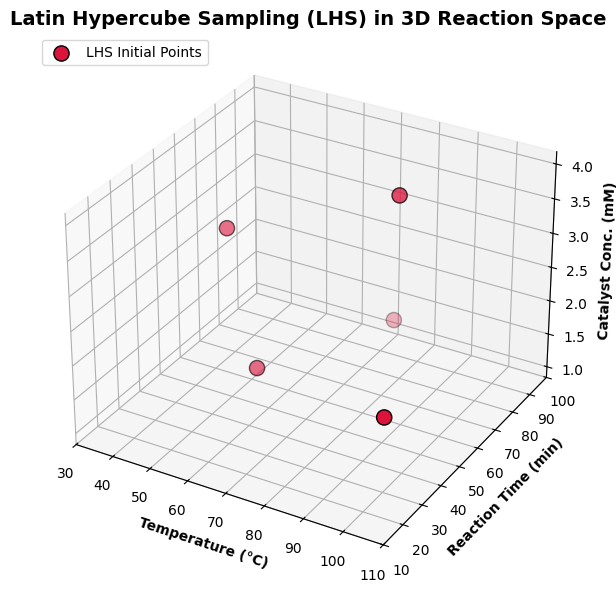

In [4]:
import numpy as np
from pyDOE import lhs  # install pyDOE

def generate_doe(bounds, num_samples):
    """
    Generate DOE samples using Latin Hypercube Sampling (LHS) and optionally evaluate them.
    Parameters:
    bounds : np.ndarray
        A 2D array of shape (n_parameters, 2) where each row specifies the lower and upper
        bound for a parameter.
    num_samples : Number of DOE samples to generate.
    Returns:
    X : np.ndarray
        DOE sampled points scaled to the provided bounds.
    """
    num_params = bounds.shape[0]
  
    # Generate normalized LHS samples (each value in [0, 1])
    normalized_samples = lhs(num_params, samples=num_samples)
  
    # Scale samples to the actual search space defined by bounds
    X = normalized_samples * (bounds[:, 1] - bounds[:, 0]) + bounds[:, 0]
    return X

# Define parameter search space (each row: [lower_bound, upper_bound])
bounds = np.array([
    [30, 110],      # Temperature (°C)
    [10, 100],      # Reaction time (min)
    [0.835, 4.175]  # Catalyst concentration (mM)
])

# Determine the number of parameters and initial samples
num_params = bounds.shape[0]
num_initial_samples = 5

# Generate DOE sample points 
X_train = generate_doe(bounds, num_initial_samples)

def plot_doe_3d(X_samples, bounds):
    """
    将生成的初始样本点在 3D 空间中可视化。
    """
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    # 采样点特征
    T = X_samples[:, 0]
    t = X_samples[:, 1]
    Ccat = X_samples[:, 2]
    
    # 绘制 3D 散点图
    ax.scatter(T, t, Ccat, c='crimson', s=120, marker='o', edgecolors='black', label='LHS Initial Points')
    
    # 设置图表边界和标签
    ax.set_xlim(bounds[0])
    ax.set_ylim(bounds[1])
    ax.set_zlim(bounds[2])
    
    ax.set_title('Latin Hypercube Sampling (LHS) in 3D Reaction Space', fontsize=14, fontweight='bold')
    ax.set_xlabel('Temperature (°C)', fontweight='bold')
    ax.set_ylabel('Reaction Time (min)', fontweight='bold')
    ax.set_zlabel('Catalyst Conc. (mM)', fontweight='bold')
    
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()


bounds = np.array([
    [30.0, 110.0],      # Temperature (°C)
    [10.0, 100.0],      # Reaction time (min)
    [0.835, 4.175]      # Catalyst concentration (mM)
])

num_initial_samples = 5

print(f"Generating {num_initial_samples} initial points using LHS...")
X_train = generate_doe(bounds, num_initial_samples)

print("\n[T(°C), t(min), Ccat(mM)]")
print(np.round(X_train, 3))

# 绘制 3D 散点图
plot_doe_3d(X_train, bounds)

## Q4: Bayesian Optimization to find the reaction condition to maximize the yield of species R

=== 开始贝叶斯优化 ===
Iter 01 | T=86.4°C, t=248.4min, Ccat=6.635mM | Yield=0.6905 | Best=0.7826
Iter 02 | T=89.1°C, t=213.6min, Ccat=10.175mM | Yield=0.7152 | Best=0.7826
Iter 03 | T=86.5°C, t=256.1min, Ccat=2.959mM | Yield=0.5850 | Best=0.7826
Iter 04 | T=77.3°C, t=162.6min, Ccat=10.175mM | Yield=0.7865 | Best=0.7865
Iter 05 | T=110.0°C, t=108.1min, Ccat=10.175mM | Yield=0.5064 | Best=0.7865
Iter 06 | T=86.0°C, t=141.8min, Ccat=10.175mM | Yield=0.7389 | Best=0.7865
Iter 07 | T=75.8°C, t=233.6min, Ccat=10.175mM | Yield=0.8178 | Best=0.8178
Iter 08 | T=63.2°C, t=300.0min, Ccat=10.175mM | Yield=0.8298 | Best=0.8298
Iter 09 | T=45.9°C, t=300.0min, Ccat=10.175mM | Yield=0.6264 | Best=0.8298
Iter 10 | T=68.7°C, t=288.7min, Ccat=10.175mM | Yield=0.8430 | Best=0.8430
Iter 11 | T=79.6°C, t=170.7min, Ccat=0.835mM | Yield=0.4592 | Best=0.8430
Iter 12 | T=83.9°C, t=264.7min, Ccat=10.175mM | Yield=0.7665 | Best=0.8430
Iter 13 | T=56.1°C, t=14.1min, Ccat=6.743mM | Yield=0.0927 | Best=0.8430
Iter 14 | T=9

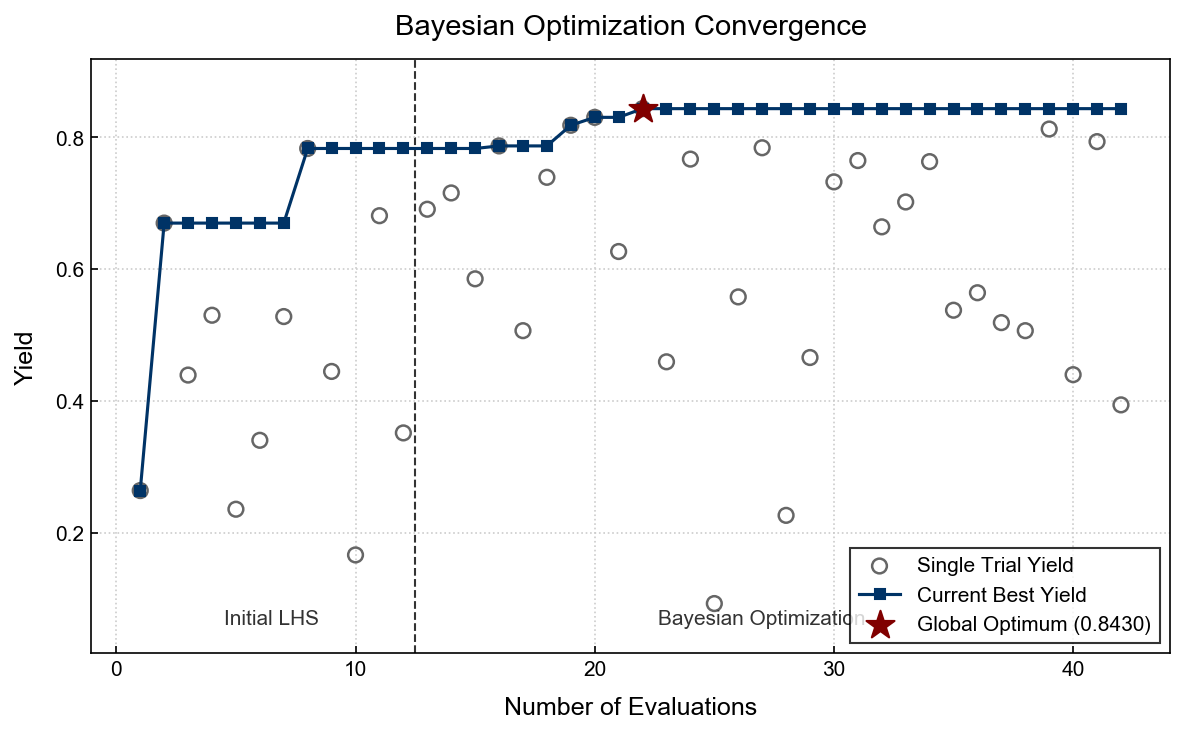

In [33]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei',
    'SimHei',
    'Microsoft JhengHei',
    'PingFang SC',
    'Heiti SC',
    'STHeiti',
    'Arial Unicode MS',
    'Noto Sans CJK SC',
    'DejaVu Sans'
 ]
plt.rcParams['axes.unicode_minus'] = False

def gaussian_process(X_train, Y_train, X_test):
    """
    定义高斯过程函数
    """
    def neg_log_marginal_likelihood(params):
        length_scale, sigma_f, noise = params
        K = matern52_kernel(X_train, X_train, sigma_f, length_scale) + (noise**2 + 1e-6) * np.eye(len(X_train))
        try:
            L = np.linalg.cholesky(K)
            alpha = np.linalg.solve(L.T, np.linalg.solve(L, Y_train))
            nlml = 0.5 * Y_train.dot(alpha) + np.sum(np.log(np.diag(L))) + 0.5 * len(X_train) * np.log(2 * np.pi)
            return nlml
        except np.linalg.LinAlgError:
            return np.inf

    # 自动搜索最优超参数
    res = minimize(neg_log_marginal_likelihood, x0=[1.0, 1.0, 0.1],
                   bounds=((1e-2,100), (1e-2, 100), (1e-6, 1.0)), method='L-BFGS-B')
    opt_l, opt_sf, opt_n = res.x

    # 计算后验
    K = matern52_kernel(X_train, X_train, opt_sf, opt_l) + (opt_n**2 + 1e-6) * np.eye(len(X_train))
    K_inv = np.linalg.pinv(K)
    k_star = matern52_kernel(X_train, X_test, opt_sf, opt_l)
    k_starstar = matern52_kernel(X_test, X_test, opt_sf, opt_l)

    mu = k_star.T.dot(K_inv).dot(Y_train)
    var = np.diag(k_starstar) - np.sum(k_star.T.dot(K_inv) * k_star.T, axis=1)
    sigma = np.sqrt(np.clip(var, 1e-9, None))
    
    return mu, sigma

def expected_improvement(mu, sigma, f_max, xi=0.01):
    with np.errstate(divide='ignore', invalid='ignore'):
        Z = (mu - f_max - xi) / sigma
        ei = (mu - f_max - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return ei

def run_bayesian_optimization():
    # 设定参数
    bounds = np.array([[30.0, 110.0], [10.0, 300.0], [0.835, 10.175]]) # 温度C，反应时间min，催化剂浓度mM
    num_initial_samples = 12
    n_iterations = 30
    xi = 0.02
    
    X_train = generate_doe(bounds, num_initial_samples)
    y_train = np.array([kinetics(x) for x in X_train])
    
    print("=== 开始贝叶斯优化 ===")
    
    # BO 迭代
    for i in range(n_iterations):
        f_max = np.max(y_train)
        
        def negative_ei(x):
            x = x.reshape(1, -1)
            mu, sigma = gaussian_process(X_train, y_train, x)
            return -expected_improvement(mu, sigma, f_max, xi)[0]
        
        best_ei = float('inf')
        best_x = None
        
        # 寻找 EI 极值点
        candidates = generate_doe(bounds, 5) 
        for cand in candidates:
            res = minimize(negative_ei, cand, bounds=bounds, method='L-BFGS-B')
            if res.success and res.fun < best_ei:
                best_ei = res.fun
                best_x = res.x
                
        if best_x is None:
            best_x = np.random.uniform(bounds[:, 0], bounds[:, 1])

        # 执行新实验
        y_next = kinetics(best_x)
        X_train = np.vstack((X_train, best_x))
        y_train = np.append(y_train, y_next)
        
        print(f"Iter {i+1:02d} | T={best_x[0]:.1f}°C, t={best_x[1]:.1f}min, Ccat={best_x[2]:.3f}mM | Yield={y_next:.4f} | Best={np.max(y_train):.4f}")
    
    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
    
    iterations = np.arange(1, len(y_train) + 1)
    best_values = np.maximum.accumulate(y_train)
    
    # 1. 画出所有的单次实验点
    ax.scatter(iterations, y_train, facecolors='none', edgecolors='#666666', 
               s=50, marker='o', linewidths=1.2, label='Single Trial Yield', zorder=2)
    
    # 2. 画出当前最优值收敛线
    ax.plot(iterations, best_values, color='#003366', linewidth=1.5, 
            marker='s', markersize=5, markerfacecolor='#003366', label='Current Best Yield', zorder=3)
    
    # 3. 区分初始采样和BO阶段的垂直线
    ax.axvline(x=num_initial_samples + 0.5, color='black', linestyle='--', linewidth=1, alpha=0.8, zorder=1)
    
    # 阶段标注
    y_min, y_max = min(y_train), max(y_train)
    y_range = y_max - y_min
    text_y_pos = y_min - y_range * 0.05
    ax.text(num_initial_samples / 2 + 0.5, text_y_pos, 'Initial LHS', ha='center', va='bottom', fontsize=10, color='#333333')
    ax.text(num_initial_samples + (n_iterations)/2, text_y_pos, 'Bayesian Optimization', ha='center', va='bottom', fontsize=10, color='#333333')
    
    # 4. 突出全局最佳点：
    best_idx = np.argmax(y_train)
    ax.scatter(best_idx + 1, y_train[best_idx], color='#800000', marker='*', 
               s=200, zorder=4, label=f'Global Optimum ({y_train[best_idx]:.4f})')
    
    # 轴标签与标题
    ax.set_xlabel('Number of Evaluations', fontsize=12, labelpad=8)
    ax.set_ylabel('Yield', fontsize=12, labelpad=8)
    ax.set_title('Bayesian Optimization Convergence', fontsize=14, pad=12)
    
    ax.grid(True, linestyle=':', color='#cccccc', zorder=0)
    
    ax.legend(loc='lower right', frameon=True, edgecolor='black', fancybox=False, fontsize=10)
    
    ax.set_ylim(y_min - y_range * 0.1, y_max + y_range * 0.1)
    plt.tight_layout()
    plt.show()

run_bayesian_optimization()